# Práctica 1. Sensado y Análisis de Audio
### Ciencia de Datos para Sensores Inteligentes/Tópicos Selectos en Sistemas Interactivos
Estudiante: Leon-Altamirano F. Z. C.

## Dataset
El dataset fue creado mediante la captura de sonidos por parte de estudiantes en entornos domésticos reales para identificar 6 actividades: Baño: Bajarle al WC. Cocina: Lavar platos. Sala: Conversación. Oficina: Música de fondo. Múltiples lugares: Pasos al caminar. Clase nula: Otros sonidos. 

Cada estudiante grabó 3 audios por clase (18 en total) con una duración de 10 segundos por audio.

El formato para los nombres de los archivos es el siguiente: ID-CLASE-MUESTRA.wav

ID:= identificador del estudiante que realizó capturó el audio.
CLASE:= indica el tipo de actividad que se está realizando en el audio.
MUESTRA:= número de muestra por cada clase.

## Importación de bibliotecas

In [1]:
import os
import sys
import re
from tqdm import tqdm

# Data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Audio
import IPython.display as ipd
from IPython.display import Audio
import librosa
import librosa.display
import soundfile as sf
import noisereduce as nr

## Procesamiento de los audios

In [2]:
dataset_path = './dataset'

In [3]:
dataset_df = pd.DataFrame(
    columns=[
        "file_name",
        "file_path",
        "student_id",
        "class_label",
        "sample_number",
        "treatment",
    ]
)

In [4]:
rows = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)
            match = re.match(r"([A-Z]+)_([A-Za-z0-9]+)_([0-9]+)\.wav", file)
            if match:
                student_id = match.group(1)
                class_label = match.group(2).lower()
                sample_number = match.group(3)

                if "test" in root.lower():
                    treatment = "test"
                else:
                    treatment = "train"
                rows.append(
                    {
                        "file_name": file,
                        "file_path": file_path,
                        "student_id": student_id,
                        "class_label": class_label,
                        "sample_number": sample_number,
                        "treatment": treatment,
                    }
                )

dataset_df = pd.concat([dataset_df, pd.DataFrame(rows)], ignore_index=True)

In [5]:
dataset_df

,file_name,file_path,student_id,class_label,sample_number,treatment
0,DISC_BANO_01.wav,./dataset\Diana Itzel\DISC_BANO_01.wav,DISC,bano,01,train
1,DISC_BANO_02.wav,./dataset\Diana Itzel\DISC_BANO_02.wav,DISC,bano,02,train
2,DISC_BANO_03.wav,./dataset\Diana Itzel\DISC_BANO_03.wav,DISC,bano,03,train
3,DISC_COCINA_01.wav,./dataset\Diana Itzel\DISC_COCINA_01.wav,DISC,cocina,01,train
4,DISC_COCINA_02.wav,./dataset\Diana Itzel\DISC_COCINA_02.wav,DISC,cocina,02,train
...,...,...,...,...,...,...
175,FZCLA_PASOS_02.wav,./dataset\Zarif León\FZCLA_PASOS_02.wav,FZCLA,pasos,02,train
176,FZCLA_PASOS_03.wav,./dataset\Zarif León\FZCLA_PASOS_03.wav,FZCLA,pasos,03,train
177,FZCLA_SALA_01.wav,./dataset\Zarif León\FZCLA_SALA_01.wav,FZCLA,sala,01,train
178,FZCLA_SALA_02.wav,./dataset\Zarif León\FZCLA_SALA_02.wav,FZCLA,sala,02,train


### Eliminación de ruido y normalización

In [6]:
def denoise_normalize_audio(file_path, sr=22050):
    # Cargar audio
    audio, sr = librosa.load(file_path, sr=sr)

    # Reducción de ruido
    audio_denoised = nr.reduce_noise(y=audio, sr=sr, stationary=True, prop_decrease=0.9)

    # Normalización
    audio_normalized = librosa.util.normalize(audio_denoised)

    return audio, audio_normalized, sr

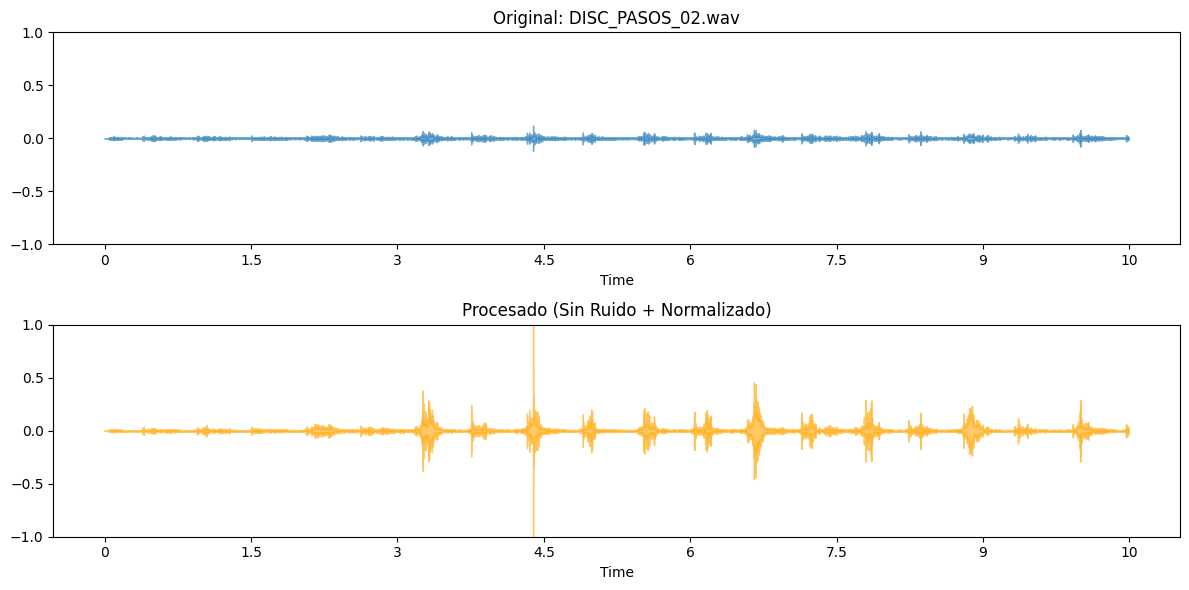

In [7]:
# Seleccionamos un archivo de ejemplo
sample_file = dataset_df.iloc[13]['file_path']

# Aplicamos la función
original, procesado, sr = denoise_normalize_audio(sample_file)

# Visualización
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.waveshow(original, sr=sr, alpha=0.6)
plt.title(f'Original: {dataset_df.iloc[13]["file_name"]}')
plt.ylim(-1, 1)

plt.subplot(2, 1, 2)
librosa.display.waveshow(procesado, sr=sr, color='orange', alpha=0.6)
plt.title('Procesado (Sin Ruido + Normalizado)')
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()

Aplicamos el procesamiento a todos los audios del dataset.

In [8]:
processed_path = './processed_dataset'
os.makedirs(processed_path, exist_ok=True)

In [10]:
save_paths = []
for index, row in tqdm(dataset_df.iterrows(), total=dataset_df.shape[0]):
    treatment = row['treatment']

    # Crear subdirectorio si no existe
    save_dir = os.path.join(processed_path, treatment)
    os.makedirs(save_dir, exist_ok=True)

    file_path = row['file_path']
    file_name = row['file_name']

    audio, audio_processed, sr = denoise_normalize_audio(file_path)

    save_path = os.path.join(save_dir, file_name)

    sf.write(save_path, audio_processed, sr)

    save_paths.append(save_path)

dataset_df['processed_file_path'] = save_paths

100%|██████████| 180/180 [00:23<00:00,  7.67it/s]


## Extracción de características
Se extraen las siguientes características de cada audio procesado:
- MFCCs (13 coeficientes)
- Zero-Crossing Rate (ZCR)
- Energía (RMS)

In [ ]:
def extract_features(file_path, sr=22050, n_mfcc=13):
    # Cargar audio
    audio, sr = librosa.load(file_path, sr=sr)

    # MFCCs
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc).mean(axis=1)

    # Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y=audio)
    zcr_mean = np.mean(zcr)

    # Energía (RMS)
    rms = librosa.feature.rms(y=audio)
    rms_mean = np.mean(rms)

    features = {
        'zcr': zcr_mean,
        'rms': rms_mean
    }

    for i, coef in enumerate(mfccs):
        features[f'mfcc_{i+1}'] = coef

    return features